# Sprawozdanie z listy 2: Budowa modelu XGBoost na danych bankowych - Jakub Sikorski

## 1. Wstęp i cel projektu
Celem niniejszego projektu jest zbudowanie zaawansowanego modelu klasyfikacyjnego opartego na algorytmie XGBoost. Zadaniem modelu jest prognozowanie, czy dany klient zdecyduje się na subskrypcję lokaty terminowej. Z punktu widzenia biznesu bankowego, precyzyjne targetowanie pozwala na optymalizację kosztów operacyjnych oraz zwiększenie efektywności prowadzonych kampanii marketingowych.

Z metodologicznego punktu widzenia, proces ten realizowany jest w ramach **uczenia nadzorowanego (Supervised Learning)**. Wybór ten wynika bezpośrednio z faktu, że dysponujemy z góry zdefiniowaną zmienną wyjściową (targetem `y`), która jednoznacznie określa historyczną decyzję klienta. Model będzie uczył się mapowania cech demograficznych i historycznych interakcji na znany wynik, aby móc dokonywać predykcji dla nowych obserwacji.

## 2. Kontekst biznesowy danych
Analizowany zbiór danych opisuje bezpośrednie kampanie marketingowe prowadzone telefonicznie przez instytucję bankową. Rekordy obejmują szeroki kontekst czasowy (od maja 2008 do listopada 2010 roku) i odzwierciedlają realia, w których często wymagany był wielokrotny kontakt telefoniczny z jednym klientem w celu pozyskania jego ostatecznej decyzji. 

Zmienne wejściowe dostarczają informacji w trzech głównych obszarach:
1. **Dane demograficzne i status społeczno-ekonomiczny klienta** (np. wiek, zawód, wykształcenie, stan cywilny).
2. **Historia finansowa klienta w banku** (np. średnie roczne saldo na koncie, posiadanie kredytów hipotecznych lub gotówkowych).
3. **Charakterystyka bieżącego oraz poprzednich kontaktów marketingowych** (np. czas trwania rozmowy, miesiąc kontaktu, wynik wcześniejszych akcji).

## 3. Struktura procesu analitycznego
1. **Eksploracyjna Analiza Danych (EDA) oraz przygotowanie danych:** Badanie statystyczne zbioru, analiza rozkładów, weryfikacja współliniowości oraz analiza zależności cech z targetem. Podział danych na zbiory (Train, Valid, Test).
2. **Budowa i optymalizacja modeli:** Sekwencyjne trenowanie modeli i porównanie ich przy użyciu miary Gini.
3. **Wybór i głęboka ewaluacja Modelu Championa:** Ostateczne wskazanie najlepszego algorytmu wraz z analizą stabilności oraz istotności zmiennych metodą SHAP.

In [116]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.inspection import permutation_importance
from skopt import BayesSearchCV
from skopt.space import Integer, Real

model_results = pd.DataFrame()

def gini(true_val, predicted_val):
    return 2 * roc_auc_score(true_val, predicted_val) - 1


def model_summary(model, nazwa, opis, xtrain, xtest, xvalid, ytrain, ytest, yvalid):
    
    y_pred_train = model.predict_proba(xtrain)[:, 1]
    y_pred_test  = model.predict_proba(xtest)[:, 1]
    y_pred_valid = model.predict_proba(xvalid)[:, 1]
    wyniki = {
        'Nazwa_modelu': nazwa,
        'Opis': opis,
        'Liczba_zmiennych': xtrain.shape[1],
        'Gini_Train [%]': round(gini(ytrain, y_pred_train), 4) * 100,
        'Gini_Valid [%]': round(gini(yvalid, y_pred_valid), 4) * 100,
        'Gini_Test [%]': round(gini(ytest, y_pred_test), 4) * 100
    }
    return pd.DataFrame([wyniki])

dane = pd.read_csv("bank-full.csv",encoding='windows-1250',sep=';')

# **CZĘŚĆ 1: EDA**

In [117]:
dane.info()
print("\nPuste wartości w zbiorze:\n", dane.isnull().sum().sum())
print("Zduplikowane wiersze:\n", dane.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Puste wartości w zbiorze:
 0
Zduplikowane wiersze:
 0


Jak widać, nasz zbiór zawiera 45211 recordów oraz 0 wartości NA i duplikatów. Oznacza to, że pod tym względem dane są gotowe do użytku. Następnie musimy zamienić wartości 'yes' i 'no' na 1 i 0 oraz ujednolicić typ danych.

In [118]:
dane['y'] = dane['y'].replace({'yes':1, 'no':0})
dane['default'] = dane['default'].replace({'yes':1, 'no':0})
dane['housing'] = dane['housing'].replace({'yes':1, 'no':0})
dane['loan'] = dane['loan'].replace({'yes':1, 'no':0})
dane = dane.reset_index()
dane = dane.rename(columns={'index':'customer_id'})

encoder_dict = {}

for col in dane.select_dtypes(include=['object','string']).columns:
    le = LabelEncoder()
    dane[col] = le.fit_transform(dane[col])
    encoder_dict[col] = le



dane.select_dtypes(include=['object','string']).columns


Index([], dtype='object')

In [119]:
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  45211 non-null  int64
 1   age          45211 non-null  int64
 2   job          45211 non-null  int32
 3   marital      45211 non-null  int32
 4   education    45211 non-null  int32
 5   default      45211 non-null  int64
 6   balance      45211 non-null  int64
 7   housing      45211 non-null  int64
 8   loan         45211 non-null  int64
 9   contact      45211 non-null  int32
 10  day          45211 non-null  int64
 11  month        45211 non-null  int32
 12  duration     45211 non-null  int64
 13  campaign     45211 non-null  int64
 14  pdays        45211 non-null  int64
 15  previous     45211 non-null  int64
 16  poutcome     45211 non-null  int32
 17  y            45211 non-null  int64
dtypes: int32(6), int64(12)
memory usage: 5.2 MB


Skoro nasze dane są już gotowe, zacznijmy od podzielenia ich na zbiory Train, Test i Valid.

In [120]:
X_train, X_testval, y_train, y_testval = train_test_split(dane[[i for i in dane.columns if i not in ['y', 'customer_id']]],
                                                          dane.y, test_size=0.4, random_state = 20)
X_test, X_valid, y_test, y_valid = train_test_split(X_testval[[i for i in dane.columns if i not in ['y', 'customer_id']]],
                                                          y_testval, test_size=0.5, random_state = 20)

print(f'TRAIN size {X_train.shape} - {X_train.shape[0]/dane.shape[0]:.2%} - target: {y_train.mean():.2%}')
print(f'TEST size {X_test.shape} - {X_test.shape[0]/dane.shape[0]:.2%} - target: {y_test.mean():.2%}')
print(f'VALID size {X_valid.shape} - {X_valid.shape[0]/dane.shape[0]:.2%} - target: {y_valid.mean():.2%}')

TRAIN size (27126, 16) - 60.00% - target: 11.80%
TEST size (9042, 16) - 20.00% - target: 11.81%
VALID size (9043, 16) - 20.00% - target: 11.29%


In [121]:
def color(value):
    if abs(value) <= 0.5:
        color = 'green'
    elif 0.5 < abs(value) <= 0.9:
        color = 'orange'
    elif abs(value) > 0.9:
        color = 'red'
    else:
        color = 'black'
    return 'color: {0}'.format(color)
    
corr = X_train.corr(method='spearman')
corr.style.applymap(color)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
age,1.000000,-0.007643,-0.442389,-0.122473,-0.008978,0.095787,-0.159100,0.001519,0.052110,-0.005239,-0.031657,-0.035340,0.039423,-0.021136,-0.015357,0.016352
job,-0.007643,1.000000,0.058030,0.175298,-0.006625,0.030658,-0.132114,-0.033111,-0.081799,0.028871,-0.083609,0.000466,0.013002,-0.011589,-0.004474,0.008030
marital,-0.442389,0.058030,1.000000,0.118449,-0.007196,0.017068,-0.019435,-0.042115,-0.041451,-0.009929,-0.007814,0.023753,-0.031496,0.034896,0.034329,-0.032562
education,-0.122473,0.175298,0.118449,1.000000,-0.016292,0.077106,-0.089475,-0.047840,-0.133428,0.028711,-0.052363,-0.003268,-0.001633,0.026745,0.035869,-0.032514
default,-0.008978,-0.006625,-0.007196,-0.016292,1.000000,-0.171970,-0.003759,0.080712,0.014283,0.015158,0.007818,-0.009074,0.009510,-0.037206,-0.038457,0.037741
balance,0.095787,0.030658,0.017068,0.077106,-0.171970,1.000000,-0.071268,-0.134028,-0.033773,-0.000125,0.025086,0.042786,-0.031260,0.065151,0.075016,-0.070182
housing,-0.159100,-0.132114,-0.019435,-0.089475,-0.003759,-0.071268,1.000000,0.043939,0.180645,-0.026027,0.269171,0.002030,-0.037167,0.084205,0.065485,-0.077694
loan,0.001519,-0.033111,-0.042115,-0.047840,0.080712,-0.134028,0.043939,1.000000,-0.009592,0.012218,0.006978,-0.012744,-0.004341,-0.029861,-0.030965,0.027755
contact,0.052110,-0.081799,-0.041451,-0.133428,0.014283,-0.033773,0.180645,-0.009592,1.000000,-0.022247,0.322395,-0.048472,0.005031,-0.276722,-0.275904,0.278167
day,-0.005239,0.028871,-0.009929,0.028711,0.015158,-0.000125,-0.026027,0.012218,-0.022247,1.000000,0.009859,-0.054542,0.133342,-0.095206,-0.090222,0.091356


Powyższa tabela przedstawia współczynnik korelacji pomiędzy zmiennymi. Większość zmiennych nie jest ze sobą silnie skorelowana. To bardzo pożądane zjawisko, ponieważ oznacza brak problemu współliniowości w naszym zbiorze. Zmienne wnoszą unikalne informacje do modelu.

In [ ]:
def get_histogram(string):
    plt.figure(figsize=(14, 6))
    plt.hist(
        [X_train[string], X_valid[string], X_test[string]], 
        bins=15, 
        label=['Treningowy (60%)', 'Walidacyjny (20%)', 'Testowy (20%)'],
    )
    plt.title(f'Rozkład {string} klientów w poszczególnych podzbiorach', fontsize=14)
    plt.xlabel(f"Wartości: {string}")
    plt.ylabel('Ilość obserwacji')
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()



def get_boxplot(string):
    plt.figure(figsize=(14, 6))
    plt.boxplot(
        [X_train[string], X_valid[string], X_test[string]], 
        labels=['Treningowy (60%)', 'Walidacyjny (20%)', 'Testowy (20%)'],
        patch_artist=True 
    )    
    plt.title(f'Wykres pudełkowy (boxplot) zmiennej {string} w poszczególnych podzbiorach', fontsize=14)
    plt.xlabel('Podzbiór danych')
    plt.ylabel(f'Wartości: {string}')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_discrete_dual(X_train, y_train, feature, slownik_encoderow=None):
    df_temp = X_train.copy()
    df_temp['y'] = y_train
    
    agg_data = df_temp.groupby(feature)['y'].agg(['count', 'mean'])
    
    if slownik_encoderow is not None and feature in slownik_encoderow:
        x_labels = slownik_encoderow[feature].inverse_transform(agg_data.index.astype(int))
    else:
        x_labels = agg_data.index.astype(str)
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    ax1.bar(x_labels, agg_data['count'], color='lightblue', edgecolor='black', alpha=0.7)
    
    ax1.set_xlabel('Kategorie', fontsize=12)
    ax1.set_ylabel('Ilość obserwacji (Wolumen)', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    ax2 = ax1.twinx()
    
    ax2.plot(x_labels, agg_data['mean'], color='red', marker='o', 
             linestyle='-', linewidth=2, markersize=8, label='Średnia (Target)')
             
    ax2.set_ylabel('Prawdopodobieństwo założenia lokaty', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, agg_data['mean'].max() * 1.2) 
    
    plt.title(f'Analiza zmiennej dyskretnej: {feature} (Tylko zbiór TRENINGOWY)', fontsize=14)
    fig.tight_layout()
    plt.show()

def plot_continuous_dual(X_train, y_train, feature, bins=5):
    df_temp = X_train.copy()
    df_temp['y'] = y_train
    
    df_temp['binned'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    
    agg_data = df_temp.groupby('binned')['y'].agg(['count', 'mean'])
    
    x_labels = agg_data.index.astype(str)
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    ax1.bar(x_labels, agg_data['count'], color='lightgreen', edgecolor='black', alpha=0.7)
    ax1.set_xlabel(f'Przedziały zmiennej: {feature}', fontsize=12)
    ax1.set_ylabel('Ilość obserwacji (Wolumen)', color='green', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='green')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    ax2 = ax1.twinx()
    ax2.plot(x_labels, agg_data['mean'], color='red', marker='o', 
             linestyle='-', linewidth=2, markersize=8)
    ax2.set_ylabel('Prawdopodobieństwo założenia lokaty', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, agg_data['mean'].max() * 1.2)
    
    plt.title(f'Analiza zmiennej ciągłej: {feature} (Tylko zbiór TRENINGOWY)', fontsize=14)
    fig.tight_layout()
    plt.show()

Jako przykład zmiennej ciągłej weźmy 'age' i przeanalizujmy jej znaczenie na wykresach.


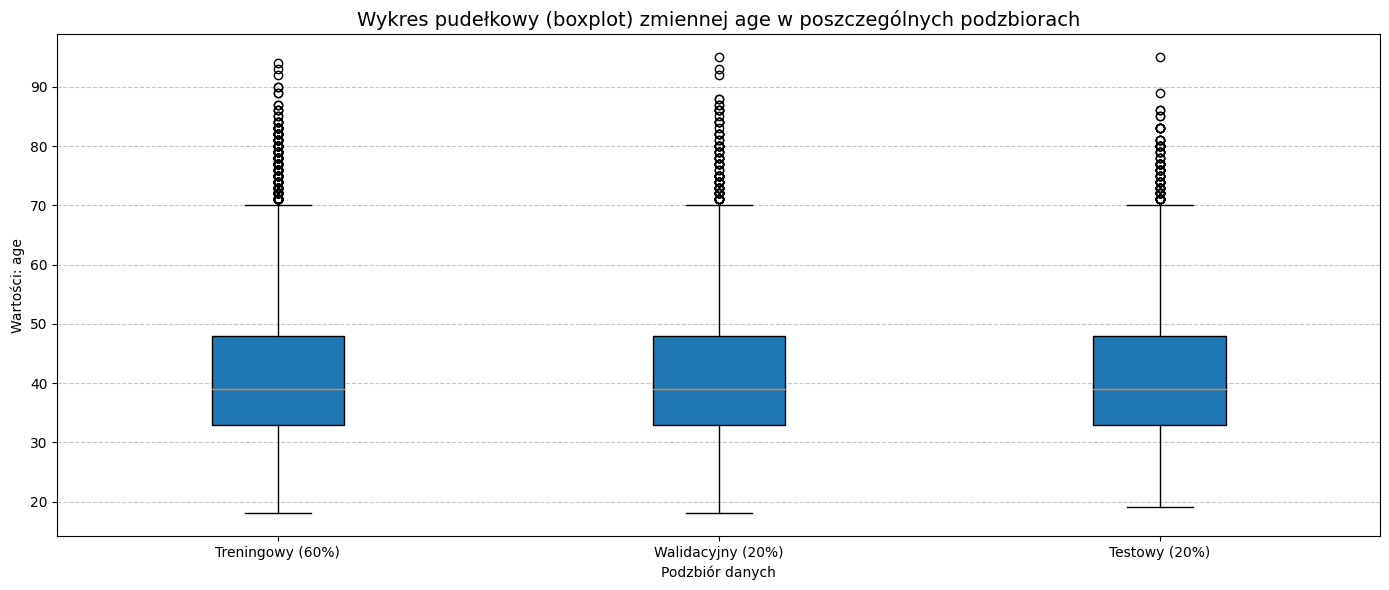

In [123]:
get_boxplot('age')

Wykresy pudełkowe potwierdzają, że rozkłady wieku w zbiorach Treningowym, Walidacyjnym i Testowym są identyczne (mediana w okolicach 39 lat). Potwierdza to, że otrzymaliśmy porządany przez nas efekt. Widzimy również sporo obserwacji odstających co jest naturalne przy danych dotyczących wieku.

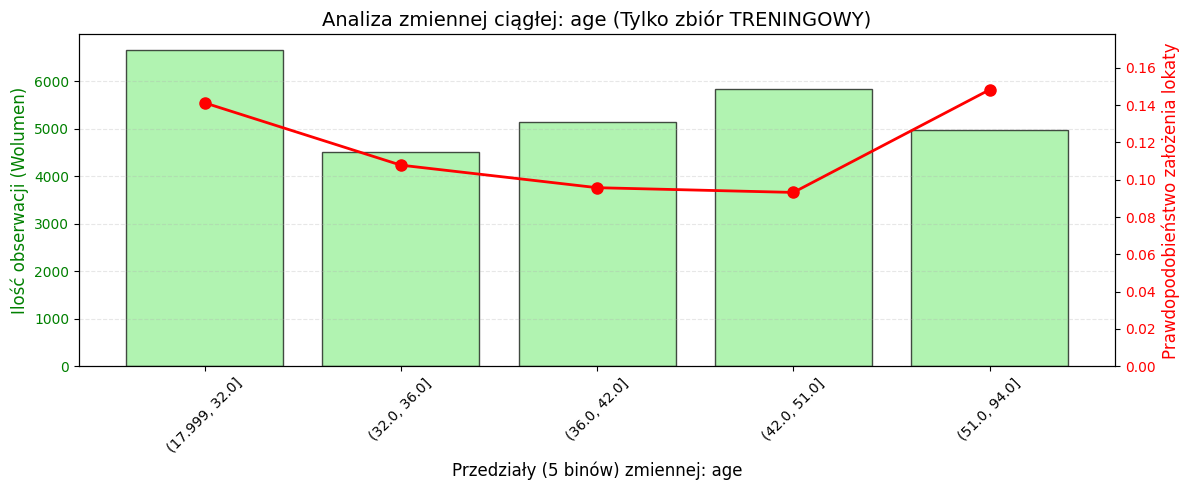

In [124]:
plot_continuous_dual(X_train, y_train, 'age')

Mimo że bank bardzo często kontaktuje się z osobami w wieku 42-51, to profil idealnego klienta ma tutaj kształt litery "U". Najwyższe prawdopodobieństwo założenia lokaty wykazują klienci najmłodsi oraz najstarsi nawet pomimo tego, że bank kontaktuje się z tymi drugimi zdecydowanie rzadziej niż z osobami w przedziale (42, 51].

Spójrzmy teraz na zmienną dyskretną 'job':

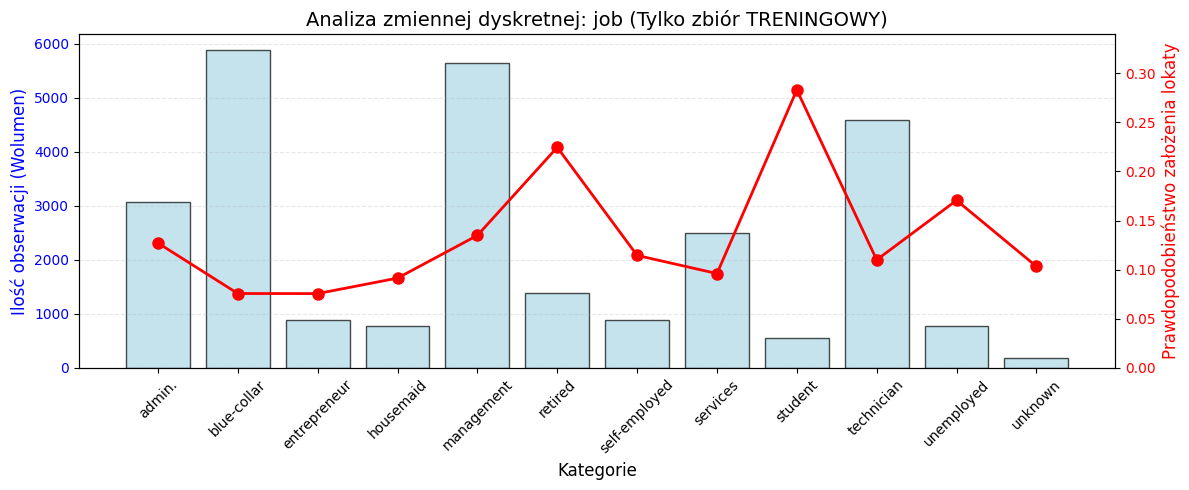

In [125]:
plot_discrete_dual(X_train, y_train, 'job', encoder_dict)

Analiza dobitnie pokazuje, że pracownicy fizyczni (blue-collar) oraz kadra zarządzająca (management) stanowią największą grupę kontaktów, jednak szansa na sprzedaż lokaty w tych grupach jest względnie niska. Zdecydowanym faworytem kampanii są grupy nieaktywne zawodowo - studenci oraz emeryci. Mimo małego wolumenu, czerwona linia prawdopodobieństwa wystrzeliwuje tam w górę, osiągając ponad 20-25%.

# **CZĘŚĆ 2: BUDOWANIE MODELI**

In [ ]:
def plot_fi_on_ax(ax, feat_names, fi_values, title, color):
    df_to_plot = pd.DataFrame({
        'zmienna': feat_names,
        'fi_values': fi_values
    }).sort_values('fi_values')

    ax.barh(df_to_plot['zmienna'], df_to_plot['fi_values'], color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Ważność', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)


def get_feats_plots(model, df_variables, y, n_repeats=10, random_state=0):
    pi_results = permutation_importance(model, df_variables, y, n_repeats=n_repeats, random_state=random_state)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

    plot_fi_on_ax(
        ax=ax1, 
        feat_names=df_variables.columns, 
        fi_values=model.feature_importances_, 
        title="Feature importance - gain",
        color='#1f77b4'
    )
    
    plot_fi_on_ax(
        ax=ax2, 
        feat_names=df_variables.columns, 
        fi_values=pi_results.importances_mean, 
        title="Permutation importance",
        color='#ff7f0e'
    )

    plt.tight_layout()
    plt.show()

dane2 = pd.read_csv("bank-full.csv",encoding='windows-1250',sep=';')
dane2['y'] = dane2['y'].replace({'yes':1, 'no':0})

dane2 = pd.get_dummies(dane2[[i for i in dane2.columns if i != 'y']])

dane2=dane2.drop(columns=['job_admin.','marital_divorced','education_primary',
                          'default_no','housing_no','loan_no',
                          'contact_cellular','month_apr','poutcome_failure'])

X_train_d = dane2.iloc[X_train.index, :].copy()
X_test_d = dane2.iloc[X_test.index, :].copy()
X_valid_d = dane2.iloc[X_valid.index, :].copy()

### Model 1: Domyślny XGBoost
Model ten stanowi nasz podstawowy punkt odniesienia. Został zbudowany przy użyciu algorytmu XGBoost ze standardowymi, domyślnymi ustawieniami hiperparametrów.

In [127]:
model1 = xgb.XGBClassifier()
model1.fit(X_train, y_train)

model_results = pd.DataFrame()

model_results = pd.concat([
    model_results,
    model_summary(
        model=model1,
        nazwa='Model 1',
        opis='Domyślne hiperparametry',
        xtrain=X_train,
        xtest=X_test,
        xvalid=X_valid,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)


### Model 2: Domyślny XGBoost (Zmienne typu Dummy)
W tym podejściu zachowano domyślne hiperparametry algorytmu XGBoost, jednak dokonano zasadniczej zmiany w sposobie reprezentacji danych wejściowych. Wszystkie wielowartościowe zmienne kategoryczne (takie jak zawód, wykształcenie czy stan cywilny) zostały przekształcone na zestaw zmiennych binarnych.

In [128]:
model2 = xgb.XGBClassifier()
model2.fit(X_train_d, y_train)

model_results = pd.concat([
    model_results,
    model_summary(
        model=model2,
        nazwa='Model 2',
        opis='Domyślne hiperparametry (Zmienne Dummy)',
        xtrain=X_train_d,
        xtest=X_test_d,
        xvalid=X_valid_d,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)

### Model 3: Optymalizacja hiperparametrów algorytmem bayesowskim
Kolejnym krokiem jest próba poprawienia wyników modelu domyślnego poprzez optymalizację jego hiperparametrów. Zamiast standardowej, metody Grid Search, wykorzystano zaawansowaną optymalizację bayesowską.

In [ ]:
model3 = xgb.XGBClassifier()

param_space = {
    'n_estimators':Integer(50,200),
    'max_depth':Integer(3,10),
    'min_child_weight':Integer(1,200),
    'learning_rate':Real(0.01,0.3,prior='log-uniform'),
    'subsample':Real(0.6,1.0),
    'colsample_bytree':Real(0.6,1.0),
    'gamma':Real(1e-4,5,prior='log-uniform'),
    'reg_lambda':Real(1e-4,10,prior='log-uniform'),
    'reg_alpha':Real(1e-4,10,prior='log-uniform')
}

grid_search1 = BayesSearchCV(
    estimator=model3,
    search_spaces=param_space,
    scoring='neg_mean_squared_error',
    n_iter=50,
    cv=3,
    verbose=3,
    random_state=42
)

grid_search1.fit(X_train,y_train)


best_params_1 = grid_search1.best_params_
best_params_1

model_results = pd.concat([
    model_results,
    model_summary(
        model=grid_search1.best_estimator_,
        nazwa='Model 3',
        opis='Optymalizacja Bayesowska',
        xtrain=X_train,
        xtest=X_test,
        xvalid=X_valid,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)
model_results

### Model 4: XGBoost na zmiennych Dummy z parametrami z bazy podstawowej
Model czwarty sprawdza hipotezę, czy hiperparametry zoptymalizowane pod kątem danych zakodowanych metodą Label Encoding sprawdzą się równie dobrze po zmianie struktury danych na Dummy.

In [130]:
model4 = xgb.XGBClassifier(**best_params_1)
model4.fit(X_train_d, y_train)

model_results = pd.concat([
    model_results,
    model_summary(
        model=model4,
        nazwa='Model 4',
        opis='Parametry z Modelu 3 użyte na Zmiennych Dummy',
        xtrain=X_train_d,
        xtest=X_test_d,
        xvalid=X_valid_d,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)
model_results

,Nazwa_modelu,Opis,Liczba_zmiennych,Gini_Train [%],Gini_Valid [%],Gini_Test [%]
0,Model 1,Domyślne hiperparametry,16,96.85,86.53,87.33
1,Model 2,Domyślne hiperparametry (Zmienne Dummy),42,96.17,86.23,87.60
2,Model 3,Optymalizacja Bayesowska,16,87.91,85.92,87.37
3,Model 4,Parametry z Modelu 3 użyte na Zmiennych Dummy,42,87.91,86.24,87.24


### Model 5: Pełna optymalizacja Bayesowska na zmiennych Dummy
Model piąty to proces optymalizacji hiperparametrów bezpośrednio na zmiennych Dummy.

In [ ]:
model5 = xgb.XGBClassifier()

param_space = {
    'n_estimators':Integer(50,200),
    'max_depth':Integer(3,10),
    'min_child_weight':Integer(1,200),
    'learning_rate':Real(0.01,0.3,prior='log-uniform'),
    'subsample':Real(0.6,1.0),
    'colsample_bytree':Real(0.6,1.0),
    'gamma':Real(1e-4,5,prior='log-uniform'),
    'reg_lambda':Real(1e-4,10,prior='log-uniform'),
    'reg_alpha':Real(1e-4,10,prior='log-uniform')
}

grid_search2 = BayesSearchCV(
    estimator=model5,
    search_spaces=param_space,
    scoring='neg_mean_squared_error',
    n_iter=50,
    cv=3,
    verbose=3,
    random_state=42
)

grid_search2.fit(X_train_d,y_train)

best_params_2 = grid_search2.best_params_

In [132]:
model_results = pd.concat([
    model_results,
    model_summary(
        model=grid_search2.best_estimator_,
        nazwa='Model 5 ',
        opis='Optymalizacja Bayesowska na Zmiennych Dummy',
        xtrain=X_train_d,
        xtest=X_test_d,
        xvalid=X_valid_d,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)
model_results

,Nazwa_modelu,Opis,Liczba_zmiennych,Gini_Train [%],Gini_Valid [%],Gini_Test [%]
0,Model 1,Domyślne hiperparametry,16,96.85,86.53,87.33
1,Model 2,Domyślne hiperparametry (Zmienne Dummy),42,96.17,86.23,87.60
2,Model 3,Optymalizacja Bayesowska,16,87.91,85.92,87.37
3,Model 4,Parametry z Modelu 3 użyte na Zmiennych Dummy,42,87.91,86.24,87.24
4,Model 5,Optymalizacja Bayesowska na Zmiennych Dummy,42,91.09,86.98,88.47


### Podsumowanie Części 2: Wybór Modelu Championa

Zestawienie wyników pięciu wygenerowanych modeli pozwala na wyciągnięcie kluczowych wniosków dotyczących wpływu hiperparametrów oraz struktury danych na zdolności predykcyjne algorytmu XGBoost:

1. **Problem przeuczenia (overfitting) w modelach bazowych:** Modele 1 oraz 2 (działające na domyślnych hiperparametrach) wykazały silną tendencję do przeuczenia. Mimo osiągnięcia miary Gini na poziomie 95-97% na zbiorze treningowym, ich zdolność do generalizacji na zbiorach walidacyjnym i testowym widocznie spadała. 
2. **Optymalizacja Modelu 5:** Co ciekawe, pełna optymalizacja bayesowska na zmiennych Dummy również doprowadziła do znacznego przeuczenia, co sugeruje, że algorytm zbyt mocno dopasował się do zmiennych.
3. **Zwycięstwo podejścia hybrydowego (Model 4):** Najlepszą architekturą okazał się **Model 4**. Zastosowanie optymalnych hiperparametrów ze zbioru bazowego i przeniesienie ich na strukturę zmiennych Dummy pozwoliło na drastyczne zredukowanie zjawiska przeuczenia. Model ten wykazuje najwyższą stabilność, osiągając jedne z najwyższych wyników na zbiorach valid i test przy najmniejszym przeuczeniu na zbiorze train.

Na podstawie powyższej analizy stabilności i mocy predykcyjnej, **Model 4 zostaje wybrany jako Model Champion**. To na nim zostaną przeprowadzone dalsze, dogłębne analizy ewaluacyjne.

# **CZĘŚĆ 3: EWALUACJA MODELU CHAMPION**

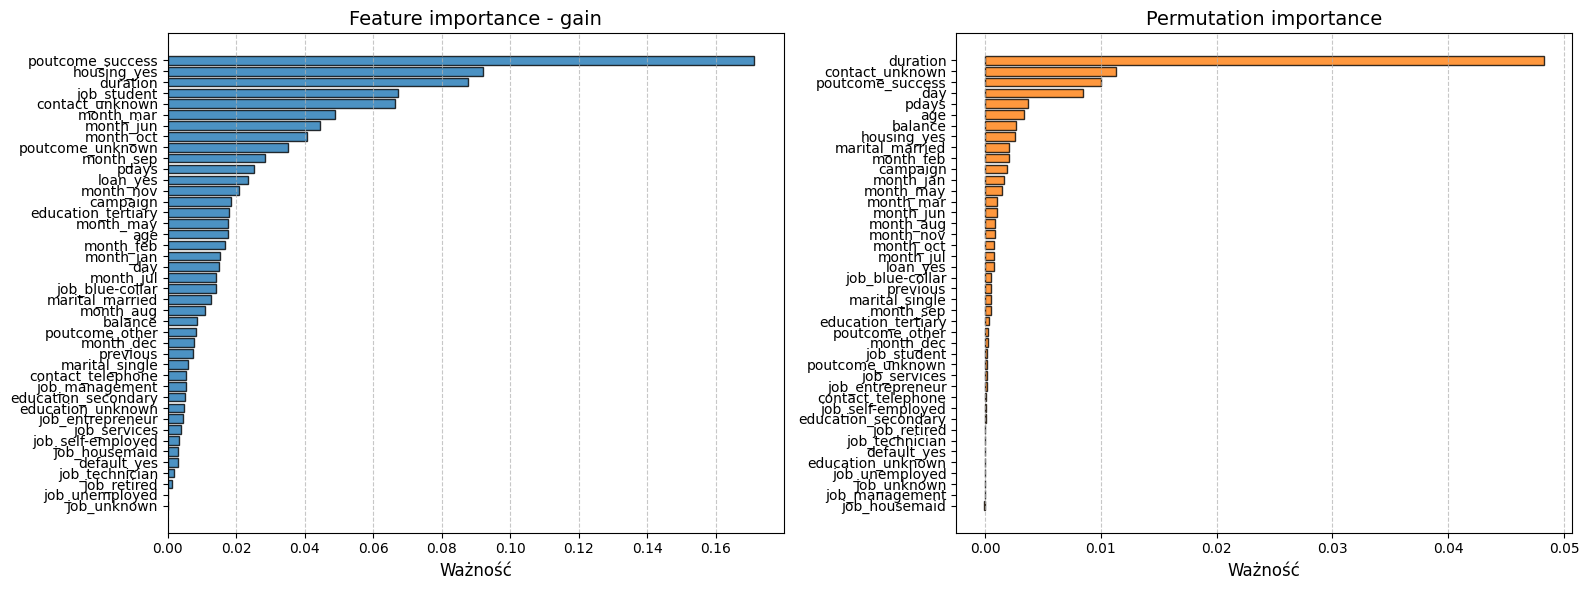

In [133]:
get_feats_plots(model4, X_train_d, y_train)

### Wnioski z analizy ważności zmiennych
Wykresy przedstawiające zysk informacyjny (gain) oraz miarę Permutation Importance jednoznacznie wskazują kluczowe zmienne decyzyjne naszego Modelu Championa. 

Zastosowanie zmiennych dummy pozwoliło nam zauważyć, że algorytm nie traktuje całych kategorii równo. Najpotężniejszą cechą w modelu okazał się wynik z poprzedniej kampanii. Dodatkowo, na szczycie ważności znalazły się parametry finansowe oraz długość trwania kontaktu. 

Widzimy również, że na samym dole rankingu znajduje się wiele zmiennych Dummy, których wkład jest znikomy. Stanowi to idealny punkt wyjścia do ostatniego kroku optymalizacji - redukcji wymiarowości, w której usuniemy najsłabsze cechy, aby jeszcze bardziej ustabilizować model.

### Selekcja zmiennych i cutoff
Analiza ważności cech wykazała, że duża część zmiennych wnosi znikomy zysk informacyjny. Obecność takich zmiennych może prowadzić do niepotrzebnego przeuczenia modelu.

W celu znalezienia optymalnej struktury danych, przeprowadzono iteracyjną eliminację cech. Algorytm stopniowo budował model, zaczynając od 5 najsilniejszych zmiennych, każdorazowo dodając kolejną i mierząc wskaźnik Gini na zbiorze treningowym i walidacyjnym. Pozwoli to zidentyfikować optymalny punkt odcięcia, w którym model maksymalizuje moc predykcyjną przy użyciu najmniejszej niezbędnej liczby wymiarów.

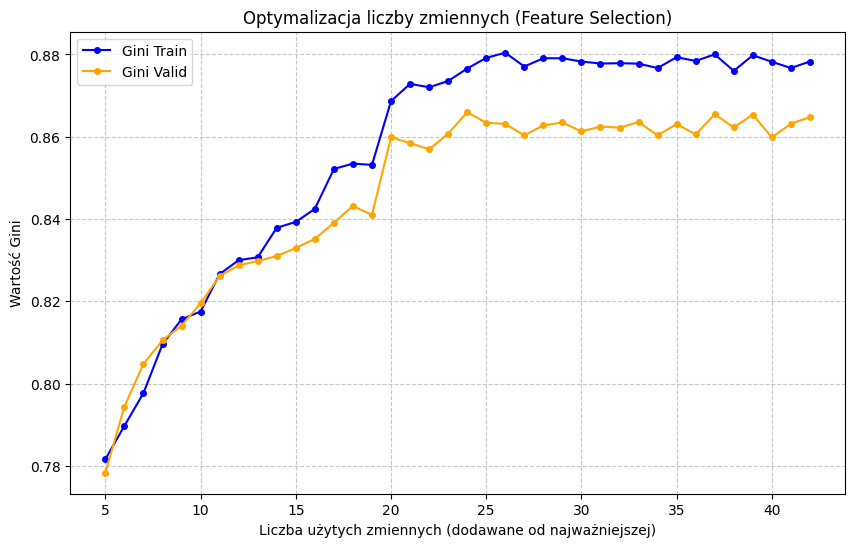

In [134]:
importances = model4.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_d.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features = feature_importance_df['Feature'].tolist()

gini_train_list = []
gini_valid_list = []
num_features_list = []

for i in range(5, len(sorted_features) + 1):
    top_features = sorted_features[:i]
    
    temp_model = xgb.XGBClassifier(**best_params_1, random_state=42)
    temp_model.fit(X_train_d[top_features], y_train)
    
    gini_train = gini(y_train, temp_model.predict_proba(X_train_d[top_features])[:, 1])
    gini_valid = gini(y_valid, temp_model.predict_proba(X_valid_d[top_features])[:, 1])
    
    gini_train_list.append(gini_train)
    gini_valid_list.append(gini_valid)
    num_features_list.append(i)

plt.figure(figsize=(10, 6))
plt.plot(num_features_list, gini_train_list, label='Gini Train', color='blue', marker='o', markersize=4)
plt.plot(num_features_list, gini_valid_list, label='Gini Valid', color='orange', marker='o', markersize=4)
plt.xlabel('Liczba użytych zmiennych (dodawane od najważniejszej)')
plt.ylabel('Wartość Gini')
plt.title('Optymalizacja liczby zmiennych (Feature Selection)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Na wykresie możemy zauważyć, że wartość Gini rośnie przy liczbie zmiennych 5-20, a następnie stabilizuje się. Jako punkt odcięcia wybrano k = 24 ponieważ od tego momentu wykres jest już bardzo stabilny.

In [135]:
k = 24
wybrane_zmienne = sorted_features[:k]

print(f"Zmienne wybrane do ostatecznego modelu:\n", wybrane_zmienne)

Zmienne wybrane do ostatecznego modelu:
 ['poutcome_success', 'housing_yes', 'duration', 'job_student', 'contact_unknown', 'month_mar', 'month_jun', 'month_oct', 'poutcome_unknown', 'month_sep', 'pdays', 'loan_yes', 'month_nov', 'campaign', 'education_tertiary', 'month_may', 'age', 'month_feb', 'month_jan', 'day', 'month_jul', 'job_blue-collar', 'marital_married', 'month_aug']


In [136]:
X_train_champ = X_train_d[wybrane_zmienne]
X_valid_champ = X_valid_d[wybrane_zmienne]
X_test_champ  = X_test_d[wybrane_zmienne]

model_champion = xgb.XGBClassifier(**best_params_1)
model_champion.fit(X_train_champ, y_train)

model_results = pd.concat([
    model_results,
    model_summary(
        model=model_champion,
        nazwa='Model Champion',
        opis=f'Model 4 + Cutoff',
        xtrain=X_train_champ,
        xtest=X_test_champ,
        xvalid=X_valid_champ,
        ytrain=y_train,
        ytest=y_test,
        yvalid=y_valid
    )
], ignore_index=True)

model_results

,Nazwa_modelu,Opis,Liczba_zmiennych,Gini_Train [%],Gini_Valid [%],Gini_Test [%]
0,Model 1,Domyślne hiperparametry,16,96.85,86.53,87.33
1,Model 2,Domyślne hiperparametry (Zmienne Dummy),42,96.17,86.23,87.60
2,Model 3,Optymalizacja Bayesowska,16,87.91,85.92,87.37
3,Model 4,Parametry z Modelu 3 użyte na Zmiennych Dummy,42,87.91,86.24,87.24
4,Model 5,Optymalizacja Bayesowska na Zmiennych Dummy,42,91.09,86.98,88.47
5,Model Champion,Model 4 + Cutoff,24,87.65,85.97,87.60


Jak możemy zauważyć, zmniejszenie liczby zmiennych odrobinę zwiększyło wynik w zbiorze walidacyjnym i zarazem obniżyło overfitting w zbiorze treningowym co sprawiło, że nasz model Champion niewątpliwie jest naszym faworytem.

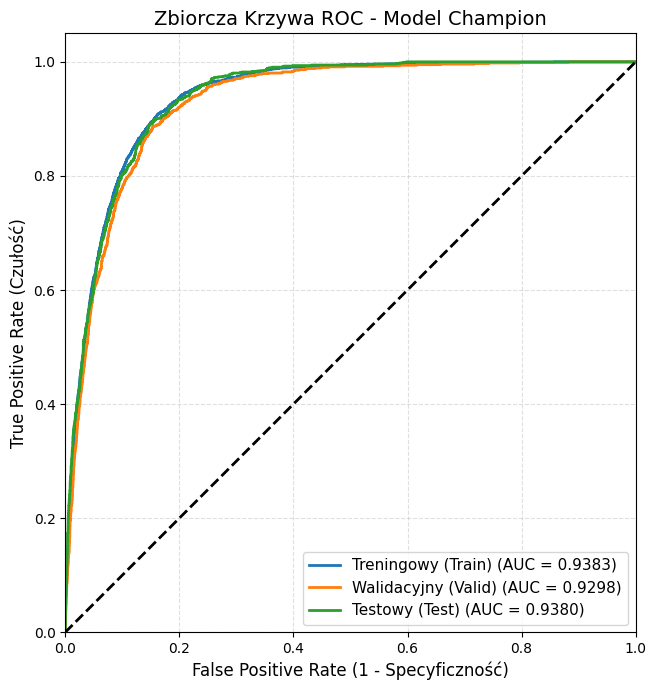

In [137]:
plt.figure(figsize=(9, 7))

datasets = [
    (X_train_champ, y_train, 'Treningowy (Train)'),
    (X_valid_champ, y_valid, 'Walidacyjny (Valid)'),
    (X_test_champ, y_test, 'Testowy (Test)')
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (X_set, y_set, name), color in zip(datasets, colors):
    y_pred_prob = model_champion.predict_proba(X_set)[:, 1]
    fpr, tpr, _ = roc_curve(y_true=y_set, y_score=y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.title('Zbiorcza Krzywa ROC - Model Champion', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specyficzność)', fontsize=12)
plt.ylabel('True Positive Rate (Czułość)', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

### Wnioski z analizy Krzywych ROC
Wykres zbiorczy krzywych ROC stanowi potwierdzenie wysokiej jakości i stabilności wybranego Modelu Championa. 

Kluczowe obserwacje:
1. **Wysoka zdolność dyskryminacyjna:** Model osiąga pole pod krzywą na poziomie ~0.938 dla zbioru testowego, co oznacza, że z blisko 94% prawdopodobieństwem oceni on wyżej klienta faktycznie zainteresowanego lokatą, niż osobę, która odmówi. 
2. **Świetna stabilność modelu:** Krzywa walidacyjna oraz testowa niemal idealnie się pokrywają. Świadczy to o braku przesunięcia rozkładu w danych pomiędzy podzbiorami i potwierdza, że model potrafi świetnie generalizować wiedzę na zupełnie nowych, nieznanych obserwacjach.

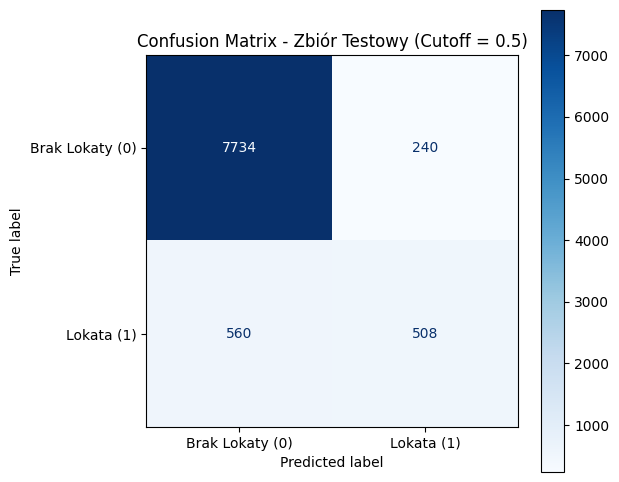

In [138]:

pred_cutoff_50 = pd.Series(model_champion.predict_proba(X_test_champ)[:,1]).apply(lambda x: 1 if x>0.5 else 0)
cm = confusion_matrix(y_true=y_test,y_pred=pred_cutoff_50)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Brak Lokaty (0)', 'Lokata (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Zbiór Testowy (Cutoff = 0.5)")
plt.show()

### Wnioski z Macierzy Konfuzji
Macierz konfuzji obliczona dla domyślnego progu odcięcia (Cutoff = 0.5) doskonale obrazuje specyfikę niezbalansowanego problemu biznesowego. 

1. **Wysoka specyficzność:** Model wykazuje dużą skuteczność w odrzucaniu klientów, którzy nie są zainteresowani lokatą. Przekłada się to na gigantyczne oszczędności w budżecie kampanii telemarketingowej.
2. **Wysoka precyzja (Precision):** Wśród wszystkich klientów, których model wytypował do kontaktu (508 + 240), aż w 68% przypadków dochodzi do założenia lokaty. Jest to bardzo dobry wynik.
3. **Kwestia progu odcięcia:** Model pominął 560 klientów, którzy w rzeczywistości założyliby lokatę. Jest to naturalne zjawisko przy domyślnym progu `0.5` na danych niezbalansowanych. Aby zmaksymalizować wolumen sprzedanych lokat, bank w warunkach produkcyjnych powinien rozważyć kalibrację i obniżenie progu odcięcia, godząc się na nieznaczny wzrost liczby zbędnych telefonów.

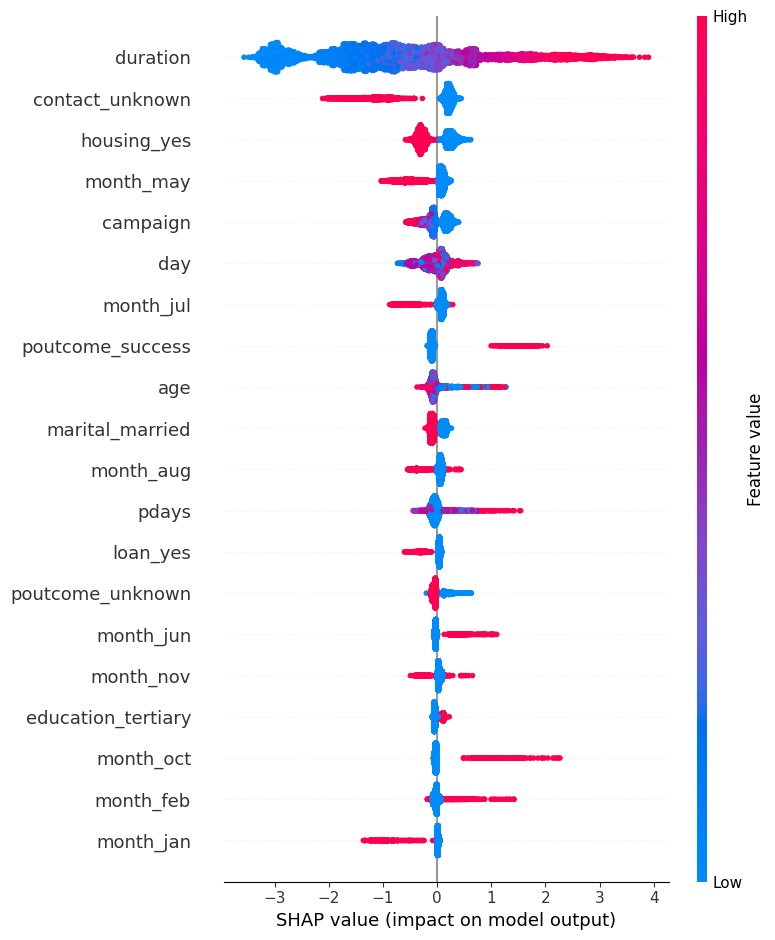

In [139]:
explainer = shap.TreeExplainer(model_champion)
shap_values = explainer.shap_values(X_test_champ)
shap.summary_plot(shap_values, X_test_champ)

### 3. Zaawansowana interpretacja modelu za pomocą wartości SHAP (Zbiór Testowy)
W przeciwieństwie do klasycznej ważności zmiennych, SHAP pokazuje nie tylko siłę danej cechy, ale przede wszystkim kierunek jej wpływu na predykcję. Kolor czerwony oznacza wysoką wartość zmiennej, a niebieski niską.

**Kluczowe obserwacje biznesowe z Modelu Champion:**

1. **`duration` (Czas rozmowy):** Najsilniejsza zmienna w modelu. Widzimy wyraźny, długi ogon czerwonych kropek po prawej stronie osi. Oznacza to, że im dłużej trwa rozmowa, tym drastycznie rośnie prawdopodobieństwo założenia lokaty. Z kolei bardzo krótkie rozmowy silnie ciągną predykcję w dół.
2. **`contact_unknown` (Nieznany kanał kontaktu):** Czerwone kropki znajdują się wyraźnie po lewej stronie. Oznacza to, że jeśli bank nie posiada sprecyzowanych danych o preferowanym kanale kontaktu z klientem, szansa na sukces kampanii drastycznie spada.
3. **`housing_yes` (Posiadanie kredytu hipotecznego):** Posiadanie kredytu przesuwa predykcję w lewo. Jest to logiczne z punktu widzenia finansów - klienci obciążeni ratą kredytu hipotecznego mają mniejszą skłonność do zamrażania kapitału na lokatach.
4. **Efekty sezonowości (np. `month_may`):** Kontakt w maju wykazuje silnie negatywny wpływ na sprzedaż lokat. Z kolei miesiące jesienne, takie jak październik (`month_oct`), wykazują silnie pozytywny wpływ.
5. **`campaign` (Liczba kontaktów w bieżącej kampanii):** Wyższe wartości wpływają negatywnie. Zbyt częste nękanie klienta telefonami podczas jednej kampanii odnosi odwrotny skutek i zniechęca go do produktu.
6. **`poutcome_success` (Sukces poprzedniej kampanii):** Mimo że zdarza się to rzadko, aktywacja tej zmiennej to najsilniejszy pozytywny sygnał dla modelu. Klient, który już raz nam zaufał, jest idealnym celem marketingowym.